In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/UGC-7596_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/UGC-7596_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [3]:
image_cut = image[77:177, 0:1890]
image_error_cut = image_error[77:177, 0:1890]

Text(0.5, 0, 'wavelength')

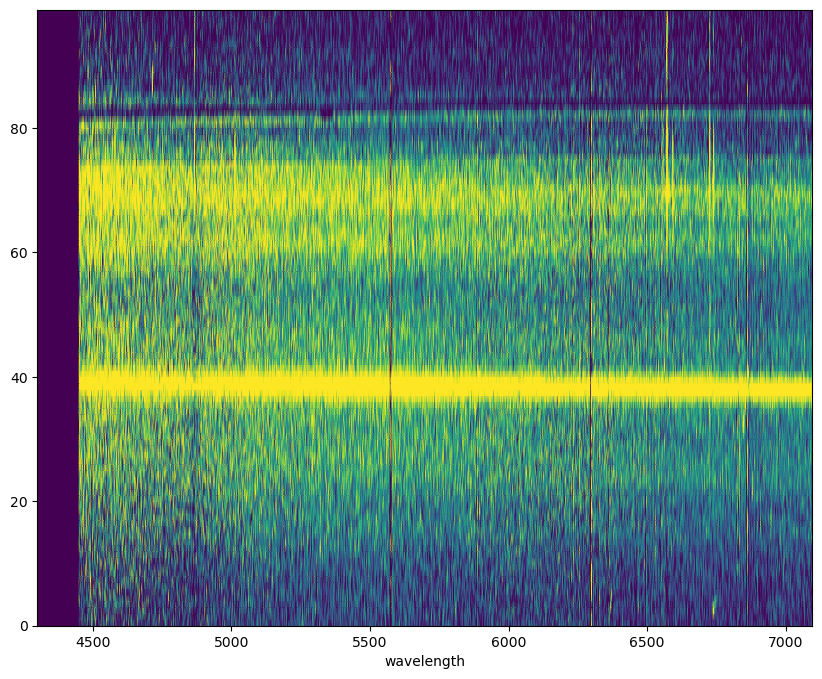

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.00189
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/PSF/Real_seeing_UGC7596.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.00975469 1.11579628 1.00705203 0.98920122 1.12349157 1.01319149]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/UGC-7596_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

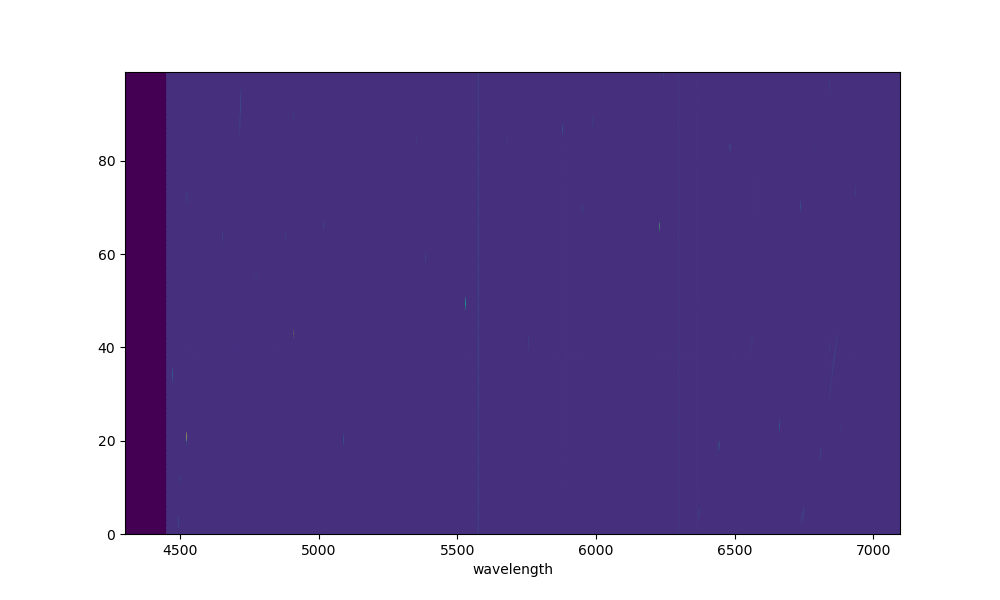

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/UGC-7596_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[77:177, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

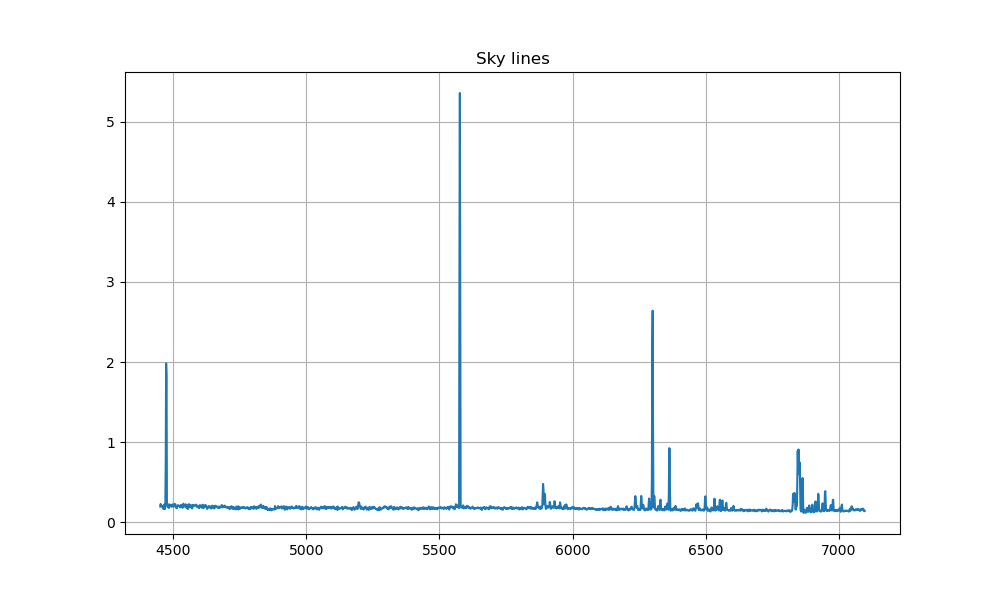

In [8]:
mask_sky = (y > 25)*(y < 35)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

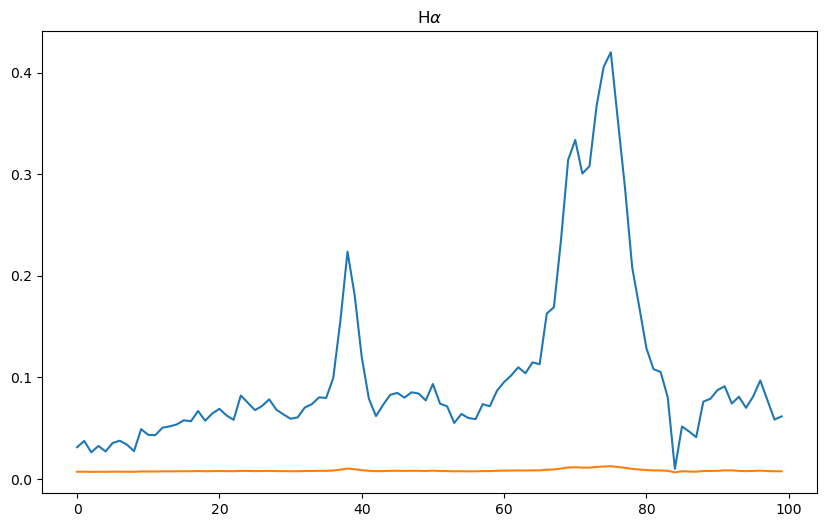

In [6]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [10]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 0.45)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 0.45)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 5),
    (0.1, 10),
    (36, 39),
    
    (0, 20),
    (0, 7),
    (0.1, 10),
    (60, 63),

    (0, 20),
    (0, 10),
    (0.1, 10),
    (69, 70),

    (0, 20),
    (0, 10),
    (0.1, 10),
    (74, 76),

    (0, 20),
    (50, 150),
    (0.1, 10),
    (40, 60),
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [11]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 26834.309164119444
differential_evolution step 2: f(x)= 26834.309164119444
differential_evolution step 3: f(x)= 26834.309164119444
differential_evolution step 4: f(x)= 9568.214774344875
differential_evolution step 5: f(x)= 9568.214774344875
differential_evolution step 6: f(x)= 4690.202684511263
differential_evolution step 7: f(x)= 4315.230372064865
differential_evolution step 8: f(x)= 2716.028664535764
differential_evolution step 9: f(x)= 2716.028664535764
differential_evolution step 10: f(x)= 2716.028664535764
differential_evolution step 11: f(x)= 2716.028664535764
differential_evolution step 12: f(x)= 2716.028664535764
differential_evolution step 13: f(x)= 2716.028664535764
differential_evolution step 14: f(x)= 2716.028664535764
differential_evolution step 15: f(x)= 2716.028664535764
differential_evolution step 16: f(x)= 2716.028664535764
differential_evolution step 17: f(x)= 2716.028664535764
differential_evolution step 18: f(x)= 2716.02866453576

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\4157967734.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=2.0720, r_e=0.0105, n=5.1247, x_0=38.0964
Sérsic 2: I_e=0.0000, r_e=0.0000, n=4.2268, x_0=62.6153
Sérsic 3: I_e=0.0572, r_e=7.2005, n=1.0009, x_0=70.0000
Sérsic 4: I_e=1.3859, r_e=0.1511, n=0.3527, x_0=75.0131
Sérsic 5: I_e=0.0523, r_e=50.0697, n=0.3080, x_0=59.9634
Chi quadro minimo: 0.06828866236959069
False


Sérsic 1: I_e=2.0720, r_e=0.0105, n=5.1247, x_0=38.0964
Sérsic 2: I_e=0.0000, r_e=0.0000, n=4.2268, x_0=62.6153
Sérsic 3: I_e=0.0572, r_e=7.2005, n=1.0009, x_0=70.0000
Sérsic 4: I_e=1.3859, r_e=0.1511, n=0.3527, x_0=75.0131
Sérsic 5: I_e=0.0523, r_e=50.0697, n=0.3080, x_0=59.9634


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\4157967734.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


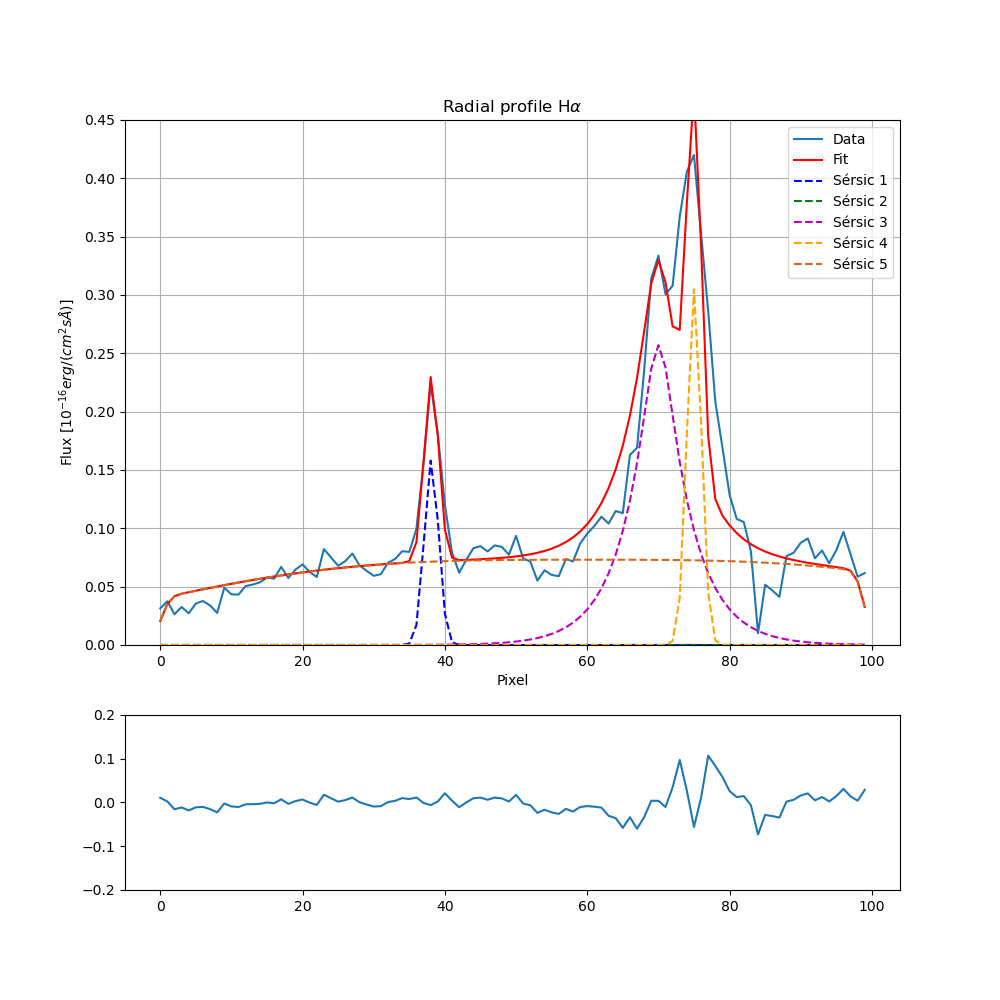

In [12]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [13]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list) #, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.0669, r_e=0.0012, n=5.1429, x_0=38.0994
Sérsic 2: I_e=0.3404, r_e=0.0097, n=4.2113, x_0=62.6118
Sérsic 3: I_e=0.0347, r_e=4.2827, n=1.3342, x_0=69.3421
Sérsic 4: I_e=0.1277, r_e=3.1092, n=0.6923, x_0=74.7707
Sérsic 5: I_e=0.0509, r_e=50.0000, n=0.3507, x_0=60.0000
[2.58953035e+06 9.49826218e+02 5.70713309e+06 2.01602645e+02
 6.65262628e+05 1.04199021e+04 4.01327424e+06 1.32572642e+03
 5.20830239e-02 4.98654547e+00 1.05905015e+00 2.18415480e-01
 2.73209866e-02 4.46974875e-01 1.56490694e-01 1.65872629e-01
 1.15014195e-02 1.17983487e+01 1.48740109e-01 3.88385240e+00]
0.227416377267196


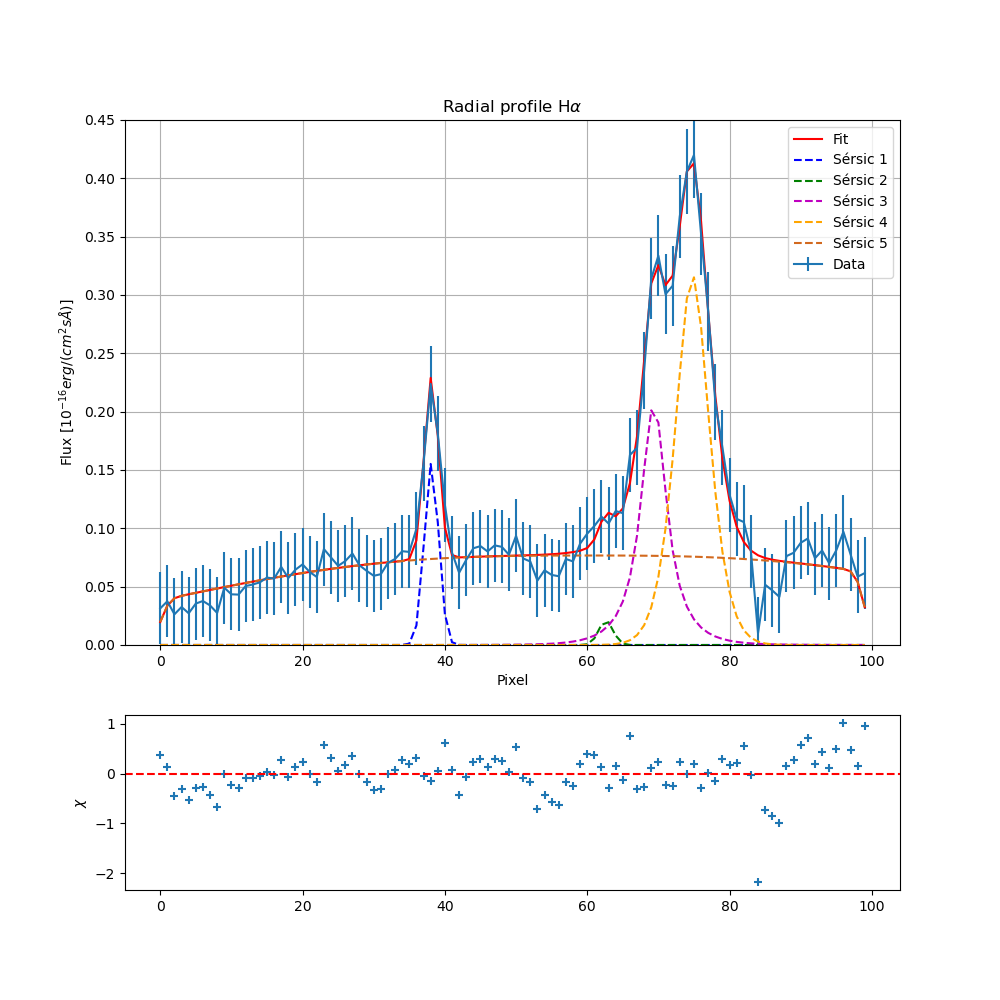

In [14]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [34]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 10),
    (0, 10),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (50, 150),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

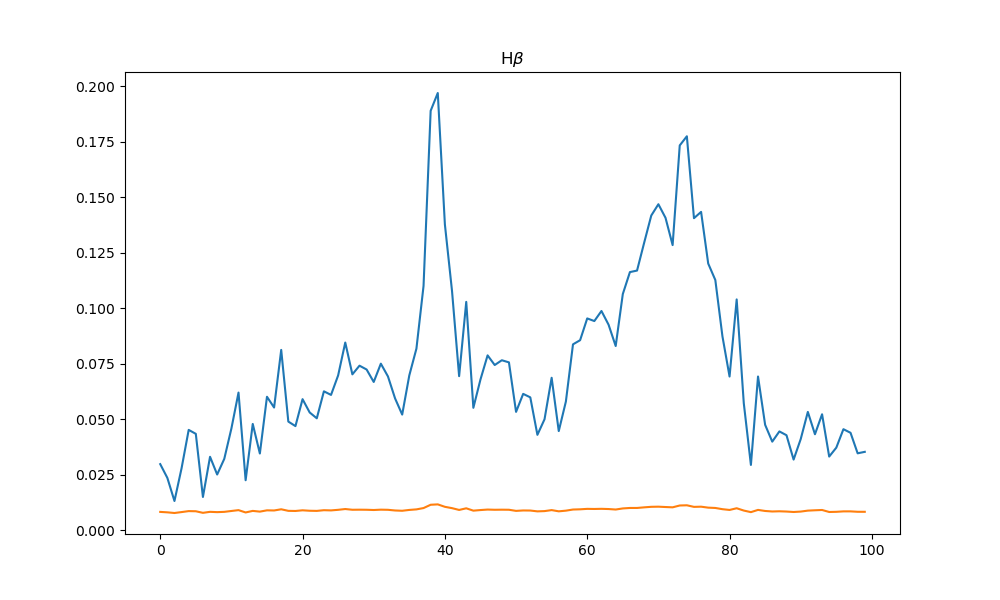

In [16]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [17]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 188050.6080238292
differential_evolution step 2: f(x)= 77056.34064240905
differential_evolution step 3: f(x)= 61635.14118438021
differential_evolution step 4: f(x)= 44735.58502909556
differential_evolution step 5: f(x)= 44735.58502909556
differential_evolution step 6: f(x)= 16388.04370573154
differential_evolution step 7: f(x)= 10882.825238101595
differential_evolution step 8: f(x)= 8523.708730680799
differential_evolution step 9: f(x)= 8523.708730680799
differential_evolution step 10: f(x)= 8523.708730680799
differential_evolution step 11: f(x)= 6203.864766369477
differential_evolution step 12: f(x)= 6203.864766369477
differential_evolution step 13: f(x)= 6203.864766369477
differential_evolution step 14: f(x)= 677.8156344245616
differential_evolution step 15: f(x)= 677.8156344245616
differential_evolution step 16: f(x)= 677.8156344245616
differential_evolution step 17: f(x)= 677.8156344245616
differential_evolution step 18: f(x)= 677.8156344245616


Sérsic 1: I_e=0.0224, r_e=2.2421, n=1.8090, x_0=38.7187
Sérsic 2: I_e=0.0279, r_e=2.3934, n=0.2193, x_0=61.6118
Sérsic 3: I_e=0.0610, r_e=4.0166, n=0.1000, x_0=70.1980
Sérsic 4: I_e=0.0385, r_e=2.6664, n=0.4544, x_0=75.9612
Sérsic 5: I_e=0.0400, r_e=50.1774, n=0.3715, x_0=58.8095


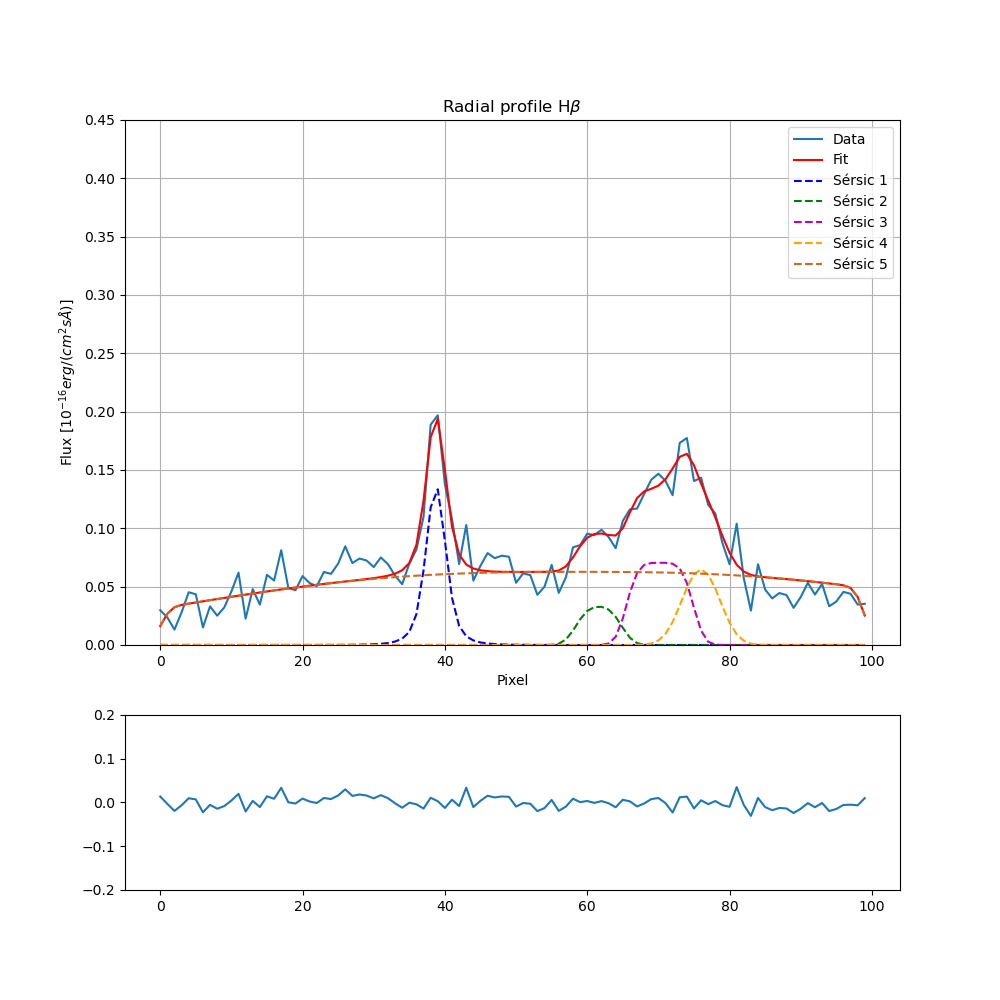

In [18]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [19]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0223, r_e=2.2423, n=1.8102, x_0=38.7187
Sérsic 2: I_e=0.0281, r_e=2.3933, n=0.2193, x_0=61.6118
Sérsic 3: I_e=0.0613, r_e=4.0165, n=0.1000, x_0=70.1980
Sérsic 4: I_e=0.0385, r_e=2.6677, n=0.4543, x_0=75.9612
Sérsic 5: I_e=0.0399, r_e=50.1774, n=0.3714, x_0=58.8095
[6.27757866e-02 3.60165014e+00 2.50596187e+00 1.47022754e-01
 2.99589432e-02 2.20810058e+00 9.61196018e-01 2.54266163e+00
 8.81077613e-02 6.08797232e+00 5.11433632e-01 1.22437823e+00
 3.15667962e-02 1.06795167e+00 7.48681168e-01 8.28092681e-01
 1.13725797e-02 1.50357083e+01 1.76312131e-01 4.21510383e+00]
0.21394279720897838


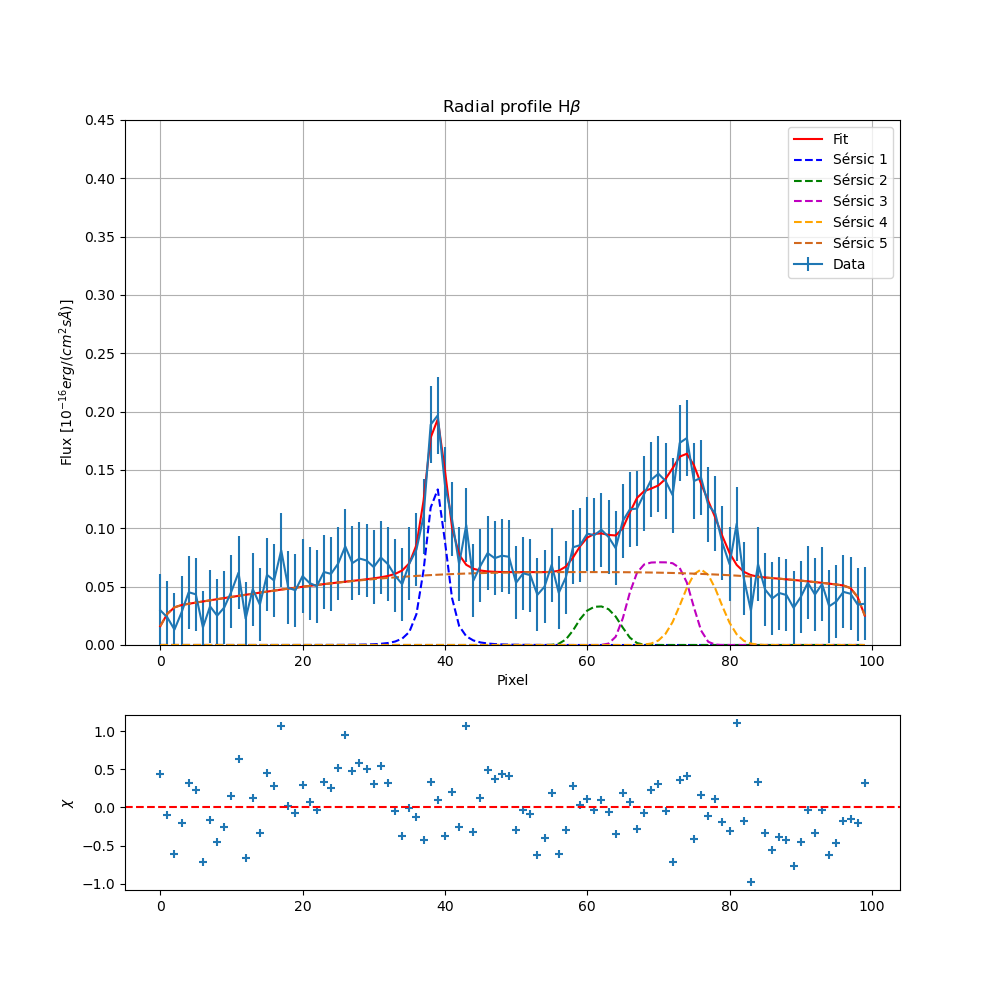

In [20]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

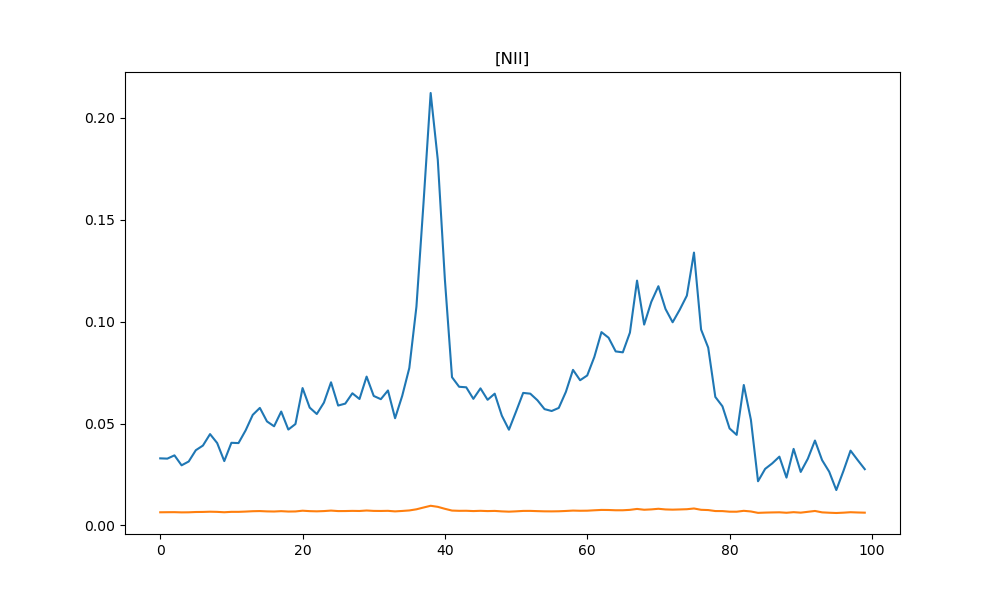

In [21]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [22]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 39397.3882662162
differential_evolution step 2: f(x)= 39397.3882662162
differential_evolution step 3: f(x)= 39397.3882662162
differential_evolution step 4: f(x)= 39397.3882662162
differential_evolution step 5: f(x)= 11759.59328077628
differential_evolution step 6: f(x)= 11759.59328077628
differential_evolution step 7: f(x)= 11759.59328077628
differential_evolution step 8: f(x)= 8491.180573389896
differential_evolution step 9: f(x)= 8491.180573389896
differential_evolution step 10: f(x)= 7001.581788252249
differential_evolution step 11: f(x)= 7001.581788252249
differential_evolution step 12: f(x)= 6482.327358285234
differential_evolution step 13: f(x)= 4663.061946614881
differential_evolution step 14: f(x)= 4663.061946614881
differential_evolution step 15: f(x)= 1876.610472544936
differential_evolution step 16: f(x)= 1348.6930714709217
differential_evolution step 17: f(x)= 1348.6930714709217
differential_evolution step 18: f(x)= 1348.6930714709217
di

Sérsic 1: I_e=0.0053, r_e=9.9853, n=2.6807, x_0=38.1245
Sérsic 2: I_e=0.0093, r_e=8.1851, n=0.8615, x_0=61.8905
Sérsic 3: I_e=0.0234, r_e=4.0592, n=0.6111, x_0=69.3581
Sérsic 4: I_e=0.0210, r_e=1.9095, n=0.9770, x_0=75.0245
Sérsic 5: I_e=0.0235, r_e=124.1774, n=0.4970, x_0=58.8439


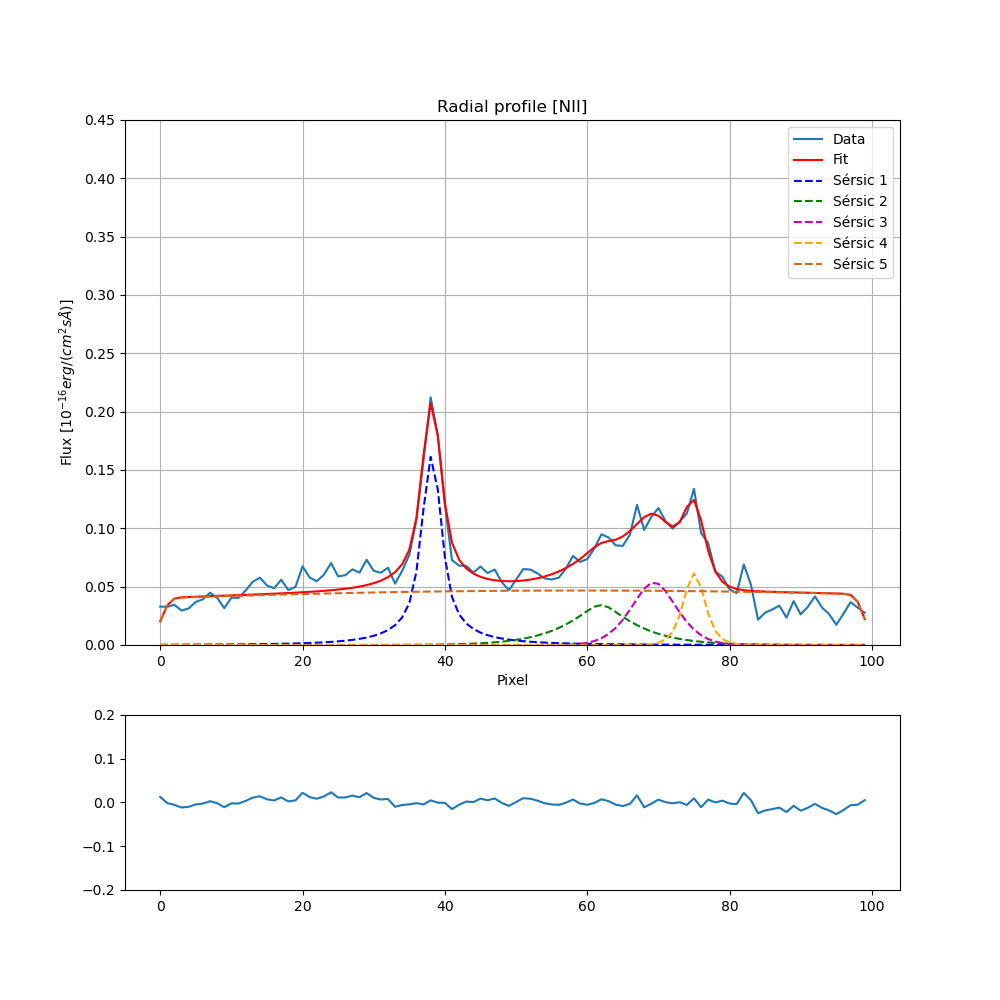

In [23]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [24]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0053, r_e=9.9853, n=2.6807, x_0=38.1245
Sérsic 2: I_e=0.0093, r_e=8.1851, n=0.8615, x_0=61.8905
Sérsic 3: I_e=0.0234, r_e=4.0592, n=0.6111, x_0=69.3581
Sérsic 4: I_e=0.0210, r_e=1.9095, n=0.9770, x_0=75.0245
Sérsic 5: I_e=0.0235, r_e=124.1774, n=0.4970, x_0=58.8439
[3.70806049e-02 4.90536268e+01 7.37991262e+00 2.45553894e-03
 2.45174093e-02 2.46948560e+01 1.34574805e+00 4.95737391e+00
 4.42084414e-02 1.23287770e+01 1.35564180e+00 1.23937362e+00
 5.54113085e-02 5.26237884e+00 2.25249533e+00 4.21663649e-01
 1.62463432e-01 1.17461163e+03 3.95319376e+00 3.84523012e+01]
0.13540157243467918


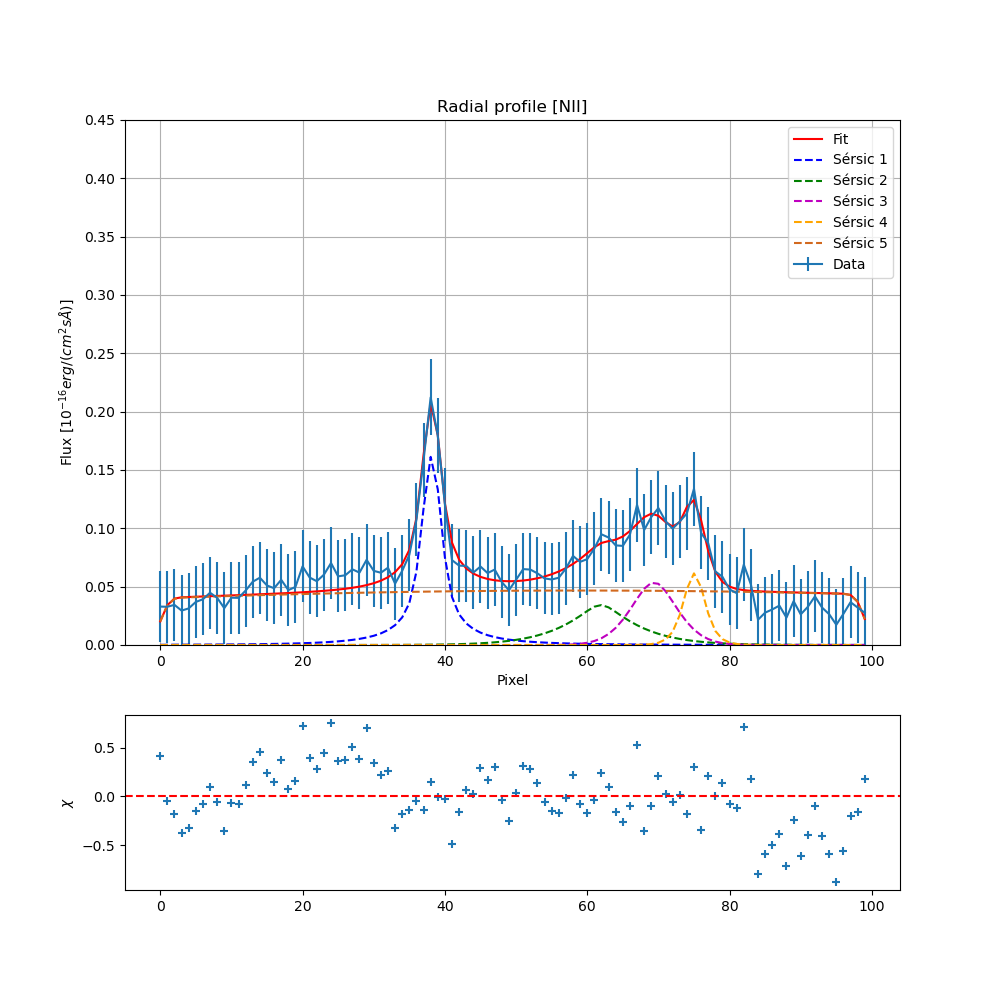

In [25]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

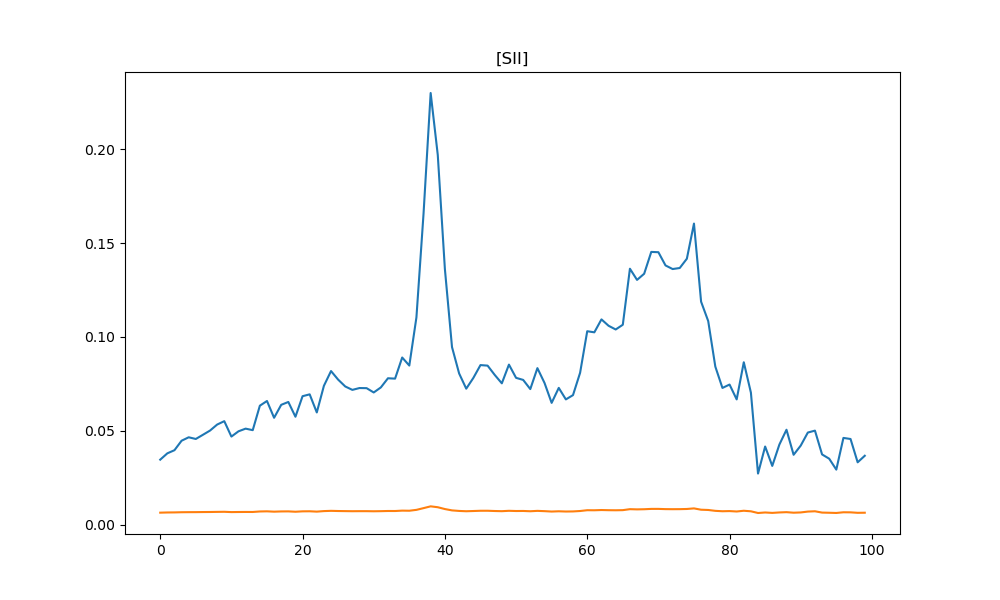

In [27]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [28]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 79841.47076189755
differential_evolution step 2: f(x)= 79841.47076189755
differential_evolution step 3: f(x)= 34108.533291448315
differential_evolution step 4: f(x)= 34108.533291448315
differential_evolution step 5: f(x)= 18758.058600726046
differential_evolution step 6: f(x)= 8976.216674614174
differential_evolution step 7: f(x)= 2699.337953976901
differential_evolution step 8: f(x)= 2699.337953976901
differential_evolution step 9: f(x)= 2699.337953976901
differential_evolution step 10: f(x)= 2699.337953976901
differential_evolution step 11: f(x)= 2699.337953976901
differential_evolution step 12: f(x)= 2699.337953976901
differential_evolution step 13: f(x)= 2699.337953976901
differential_evolution step 14: f(x)= 2699.337953976901
differential_evolution step 15: f(x)= 2699.337953976901
differential_evolution step 16: f(x)= 1757.0529900005229
differential_evolution step 17: f(x)= 1757.0529900005229
differential_evolution step 18: f(x)= 1757.052990000

Sérsic 1: I_e=0.0110, r_e=4.9050, n=2.2333, x_0=38.1951
Sérsic 2: I_e=0.0166, r_e=0.7948, n=0.6528, x_0=61.6555
Sérsic 3: I_e=0.0394, r_e=5.4537, n=0.4685, x_0=70.1874
Sérsic 4: I_e=0.6587, r_e=0.0107, n=4.1947, x_0=75.0151
Sérsic 5: I_e=0.0214, r_e=117.5689, n=0.7789, x_0=58.8095


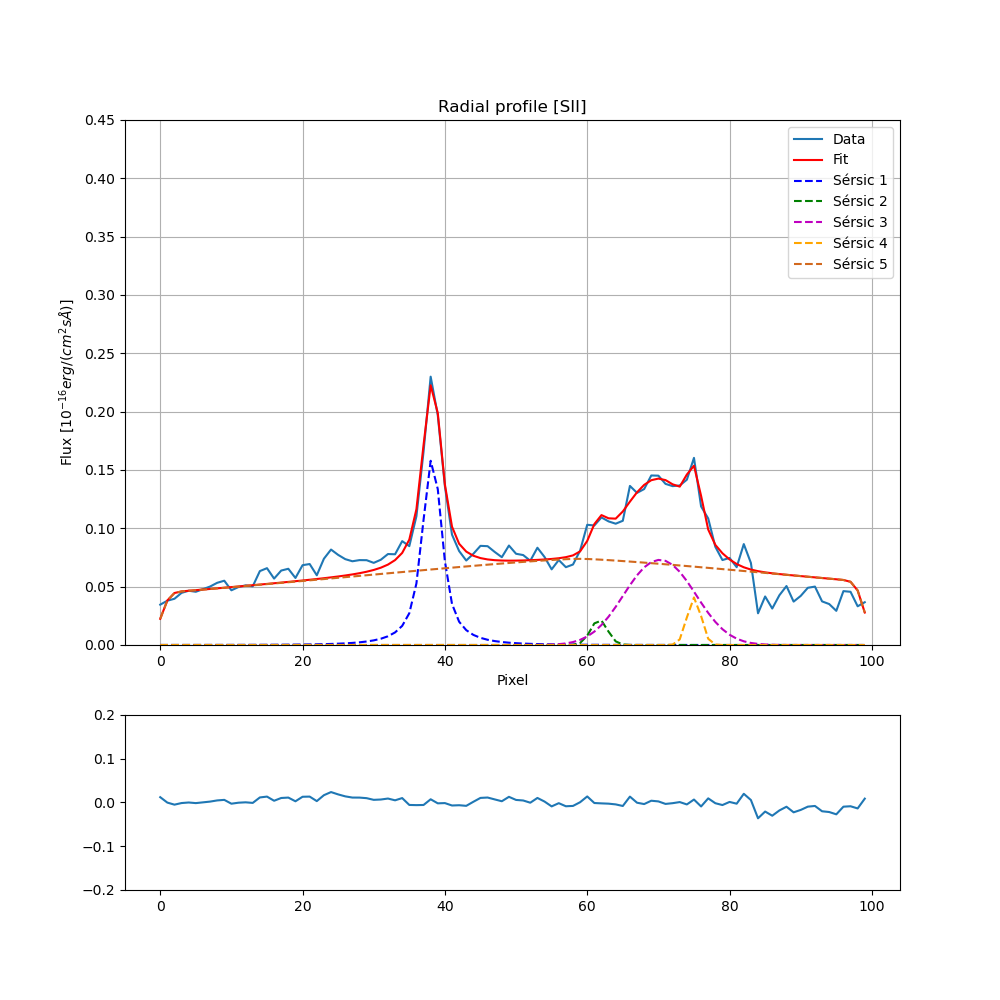

In [29]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [30]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0061, r_e=7.5345, n=2.6881, x_0=38.1988
Sérsic 2: I_e=0.0200, r_e=1.1527, n=0.3398, x_0=61.6166
Sérsic 3: I_e=0.0423, r_e=5.2142, n=0.4355, x_0=70.2574
Sérsic 4: I_e=0.6593, r_e=0.0156, n=4.1944, x_0=75.0175
Sérsic 5: I_e=0.0215, r_e=118.3076, n=0.7676, x_0=58.8095
[5.48998687e-02 4.54473477e+01 1.03951085e+01 7.56824987e-03
 1.27871720e-01 2.14625889e+00 5.40772589e+00 7.52873703e-01
 3.08246552e-02 1.65506844e+00 4.34181127e-01 2.03955189e+00
 1.33344169e+05 1.81060206e+03 4.73226772e+05 1.60760984e+02
 3.07386567e-02 2.14200832e+02 7.30709057e-01 9.97131775e+00]
0.14629499629613849


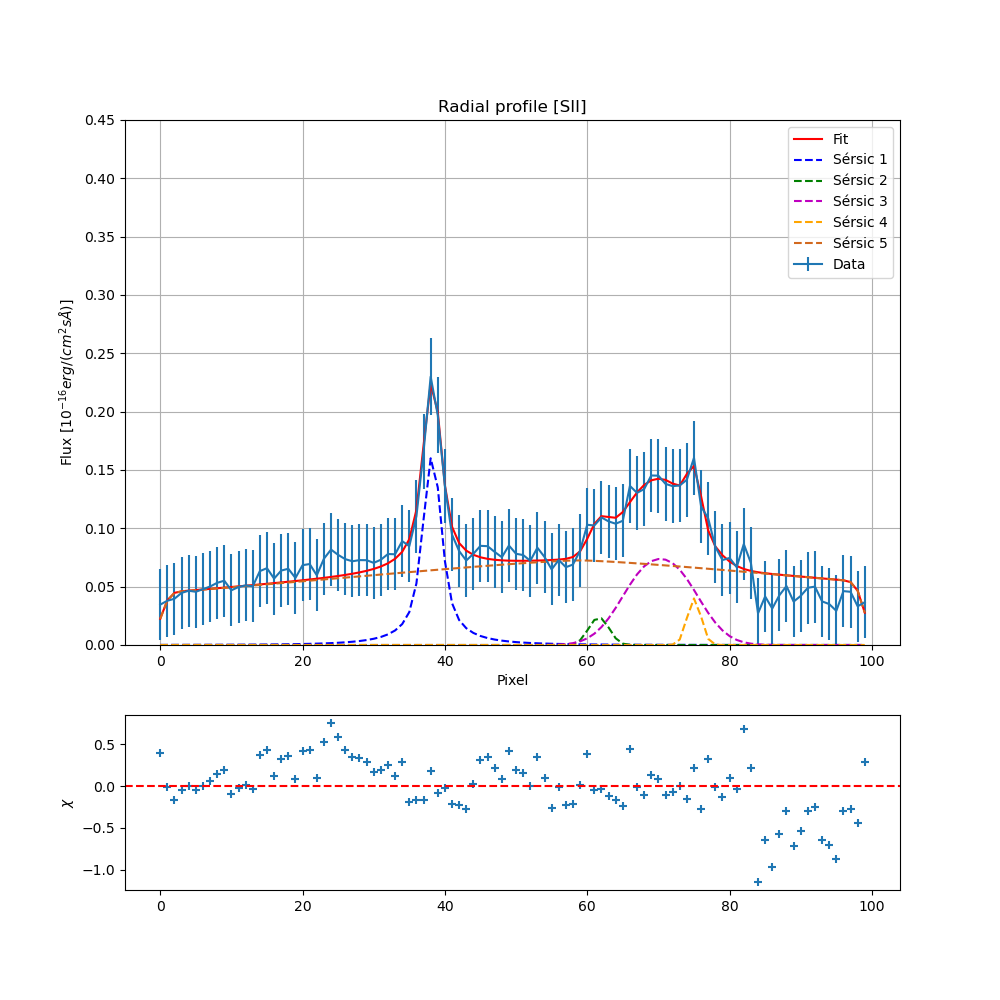

In [31]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

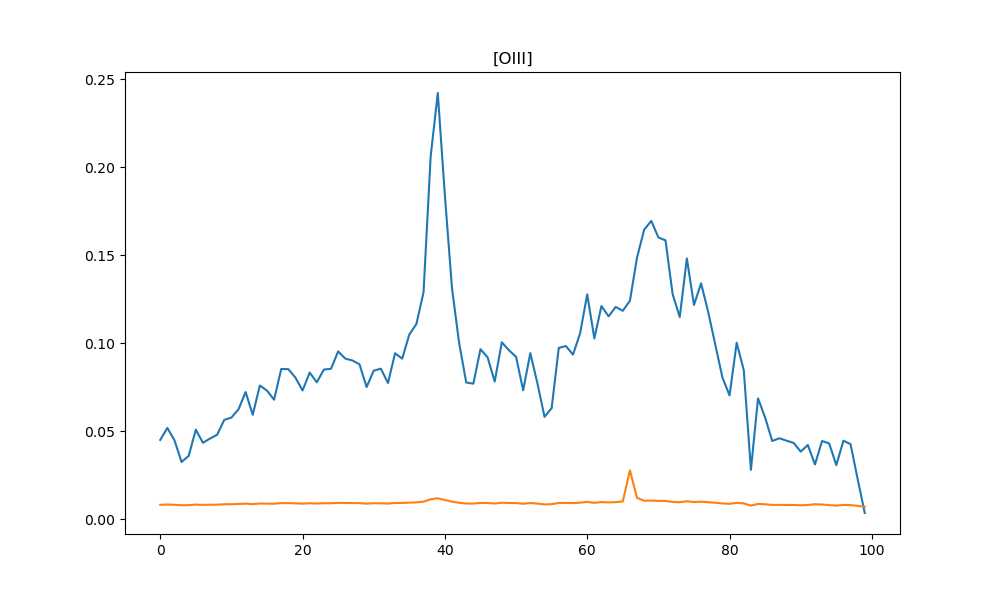

In [35]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [36]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 104549.05251994806
differential_evolution step 2: f(x)= 18976.48904044121
differential_evolution step 3: f(x)= 18976.48904044121
differential_evolution step 4: f(x)= 18976.48904044121
differential_evolution step 5: f(x)= 16636.376652911007
differential_evolution step 6: f(x)= 4411.2947856512565
differential_evolution step 7: f(x)= 4411.2947856512565
differential_evolution step 8: f(x)= 3912.963592676665
differential_evolution step 9: f(x)= 3912.963592676665
differential_evolution step 10: f(x)= 3724.1178578481026
differential_evolution step 11: f(x)= 3724.1178578481026
differential_evolution step 12: f(x)= 3724.1178578481026
differential_evolution step 13: f(x)= 2126.618890817922
differential_evolution step 14: f(x)= 2126.618890817922
differential_evolution step 15: f(x)= 1723.9696760792735
differential_evolution step 16: f(x)= 1723.9696760792735
differential_evolution step 17: f(x)= 1723.9696760792735
differential_evolution step 18: f(x)= 1723.9696

Sérsic 1: I_e=0.0056, r_e=9.9129, n=2.6904, x_0=38.8253
Sérsic 2: I_e=0.0072, r_e=7.3119, n=1.0047, x_0=61.6886
Sérsic 3: I_e=0.0264, r_e=5.1498, n=0.8617, x_0=69.5484
Sérsic 4: I_e=0.2713, r_e=0.1254, n=0.4144, x_0=75.8473
Sérsic 5: I_e=0.0303, r_e=97.6904, n=0.5990, x_0=58.8095


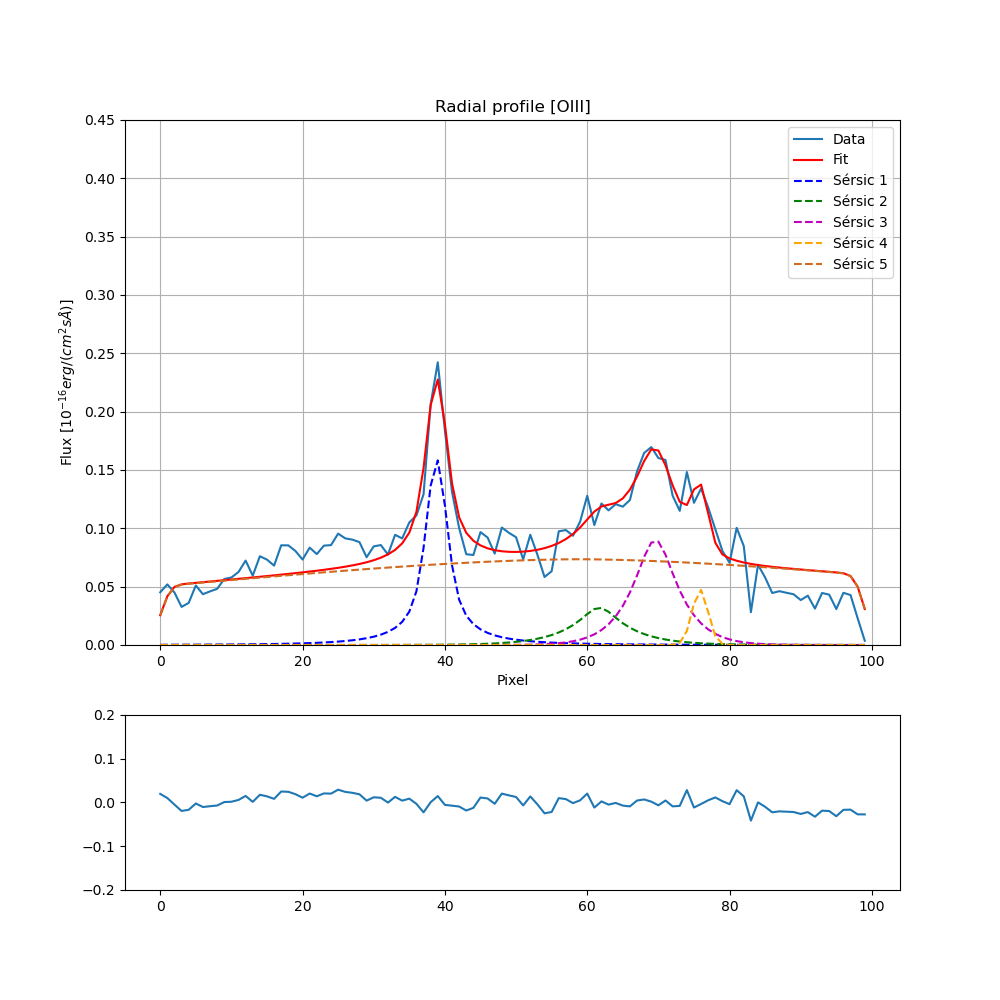

In [37]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [38]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0059, r_e=9.9398, n=2.5999, x_0=38.8177
Sérsic 2: I_e=0.0078, r_e=7.2917, n=0.9432, x_0=61.6536
Sérsic 3: I_e=0.0269, r_e=5.3222, n=0.8427, x_0=69.5625
Sérsic 4: I_e=0.1739, r_e=0.1956, n=0.3969, x_0=75.8774
Sérsic 5: I_e=0.0307, r_e=97.8080, n=0.5817, x_0=58.8095
[7.97679011e-02 9.64206552e+01 1.37851919e+01 7.44383404e-03
 3.45076934e-02 4.96276986e+01 3.26079452e+00 2.67120981e+00
 3.31666556e-02 6.75654374e+00 7.57757971e-01 7.30547963e-01
 7.36118875e+02 2.22709938e+01 4.28954133e+03 4.81175312e-01
 1.08834449e-01 3.67435208e+02 2.27861086e+00 2.33401095e+01]
0.31405552131610615


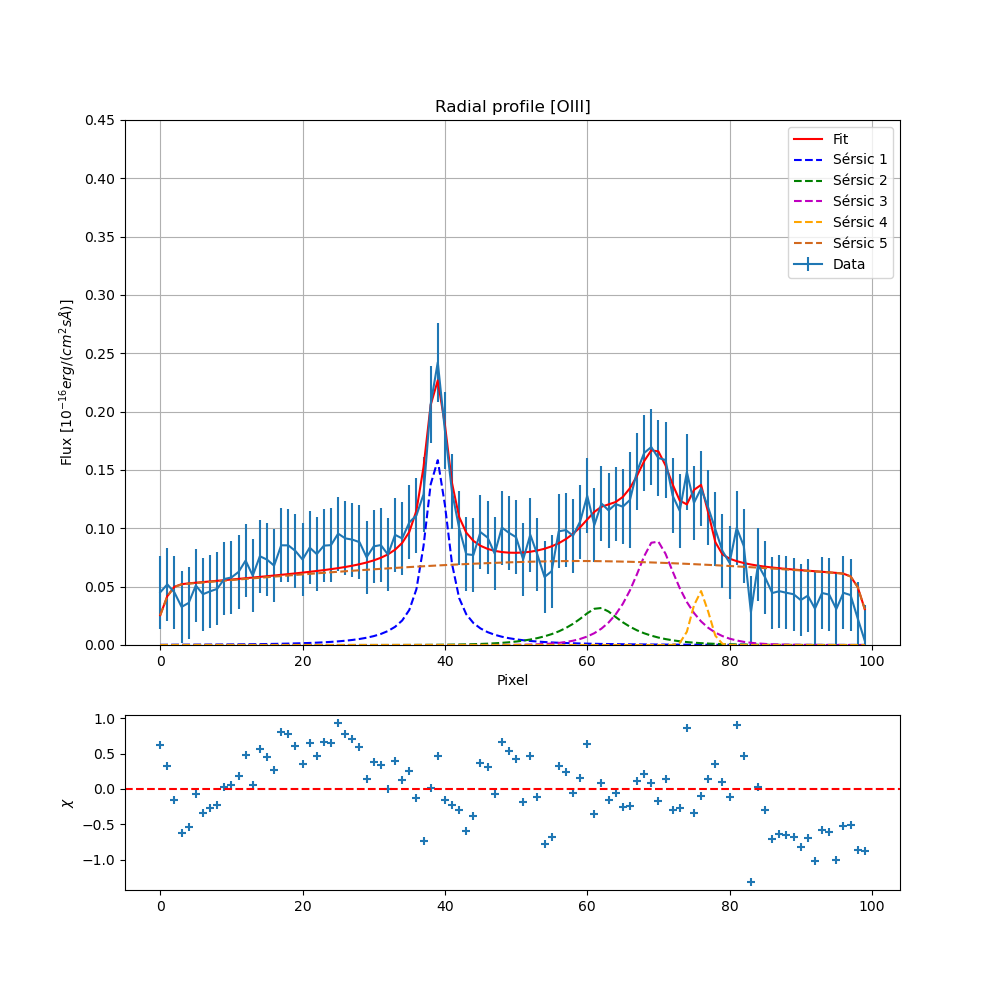

In [39]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [40]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\1978099152.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,6))


Text(0.5, 1.0, 'Continuum 1')

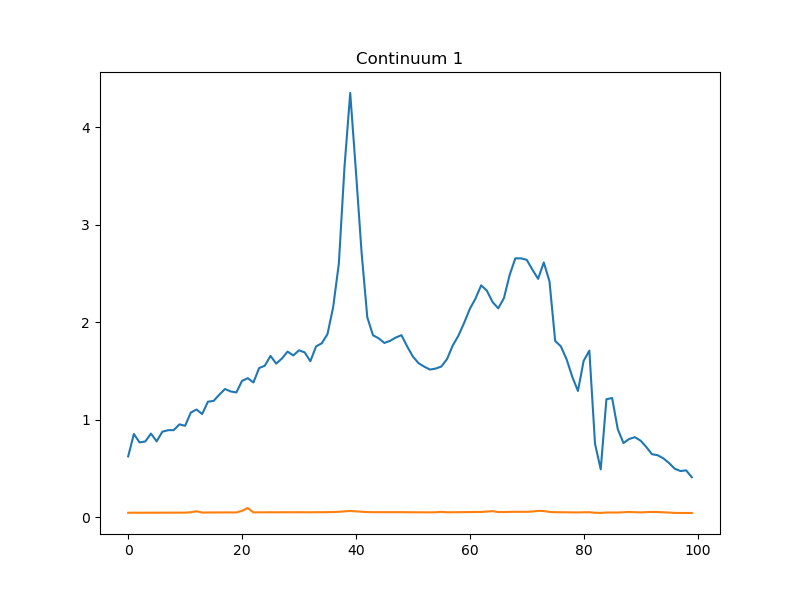

In [41]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [42]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 77772.10906396777
differential_evolution step 2: f(x)= 63909.40404543136
differential_evolution step 3: f(x)= 15150.582693845661
differential_evolution step 4: f(x)= 15150.582693845661
differential_evolution step 5: f(x)= 2851.097293902116
differential_evolution step 6: f(x)= 2851.097293902116
differential_evolution step 7: f(x)= 2851.097293902116
differential_evolution step 8: f(x)= 2851.097293902116
differential_evolution step 9: f(x)= 2851.097293902116
differential_evolution step 10: f(x)= 2851.097293902116
differential_evolution step 11: f(x)= 689.7007271442666
differential_evolution step 12: f(x)= 689.7007271442666
differential_evolution step 13: f(x)= 689.7007271442666
differential_evolution step 14: f(x)= 436.537628828911
differential_evolution step 15: f(x)= 436.537628828911
differential_evolution step 16: f(x)= 436.537628828911
differential_evolution step 17: f(x)= 436.537628828911
differential_evolution step 18: f(x)= 301.4224597588701
dif

In [43]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=2.0892, r_e=0.7814, n=0.5560, x_0=38.9569
Sérsic 2: I_e=0.5056, r_e=3.1339, n=0.5075, x_0=61.9289
Sérsic 3: I_e=0.9717, r_e=3.5104, n=0.1067, x_0=69.9923
Sérsic 4: I_e=0.2361, r_e=9.4885, n=0.7712, x_0=75.6907
Sérsic 5: I_e=0.5045, r_e=56.9200, n=0.8504, x_0=40.0777


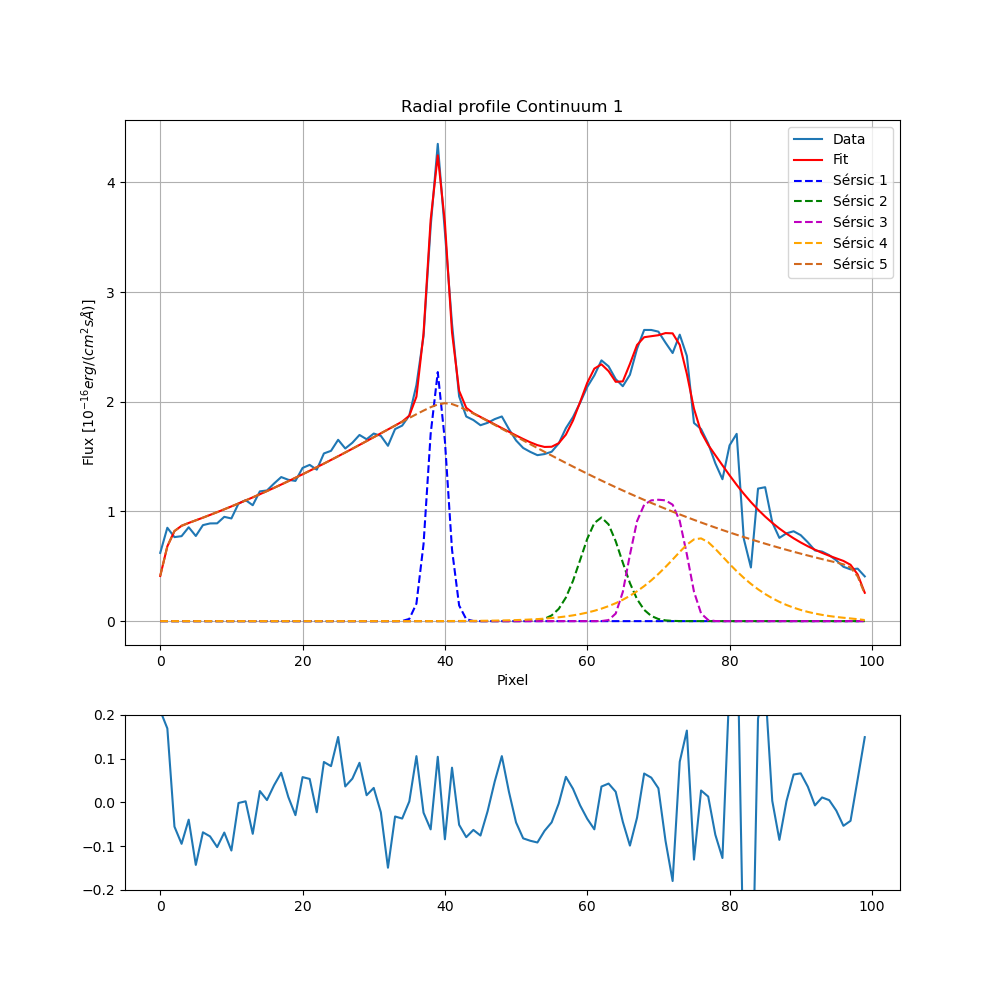

In [44]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [45]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.6794, r_e=0.8353, n=0.7397, x_0=38.9550
Sérsic 2: I_e=0.5442, r_e=3.1772, n=0.4968, x_0=61.9517
Sérsic 3: I_e=1.0750, r_e=3.5188, n=0.1000, x_0=70.0000
Sérsic 4: I_e=0.1418, r_e=10.0000, n=1.1190, x_0=76.0000
Sérsic 5: I_e=0.4740, r_e=59.9025, n=0.8828, x_0=40.0000
[ 6.43343054  0.81299195  3.81125093  0.14617583  0.31153609  1.14304346
  0.42166211  0.85327063  1.3277823   3.97007897  0.37103372  0.92750605
  0.22902789 10.34437045  0.89274271  3.32525802  0.15600499 17.21302175
  0.21008401  1.21846804]
3.6522752260866773


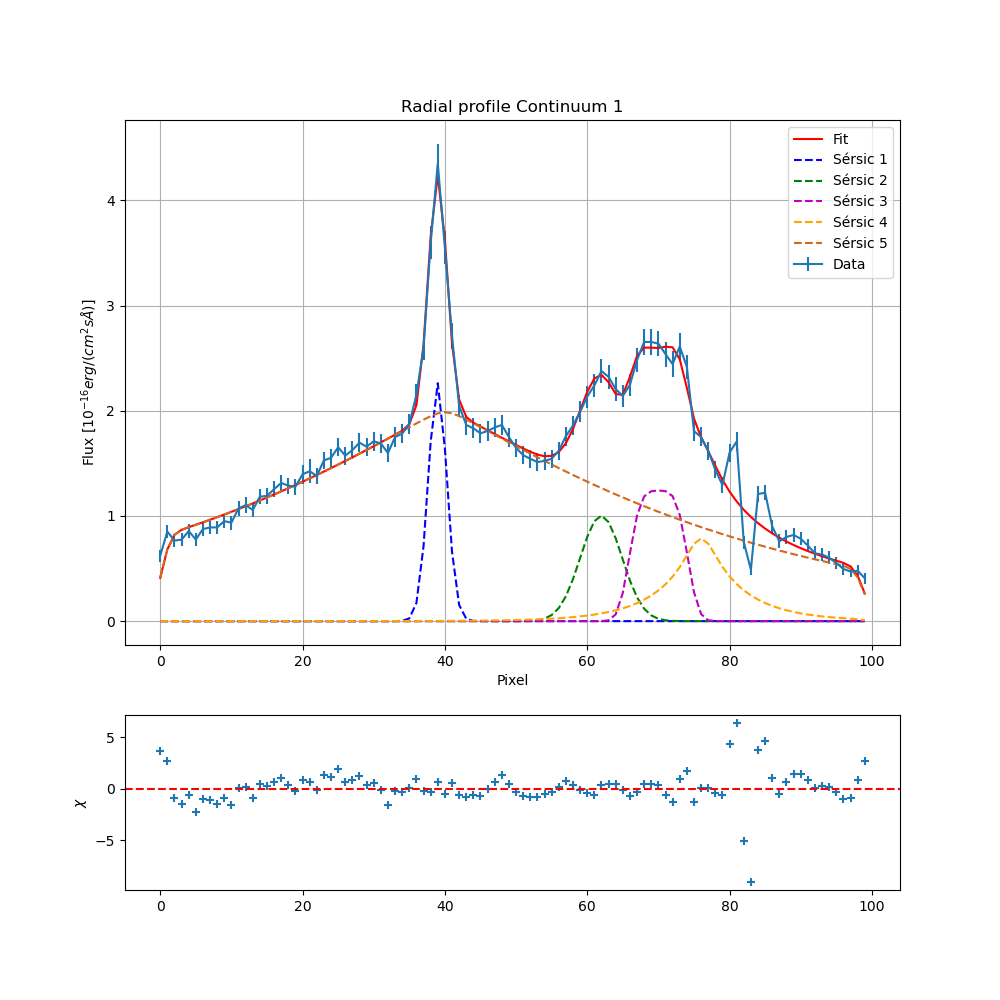

In [46]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

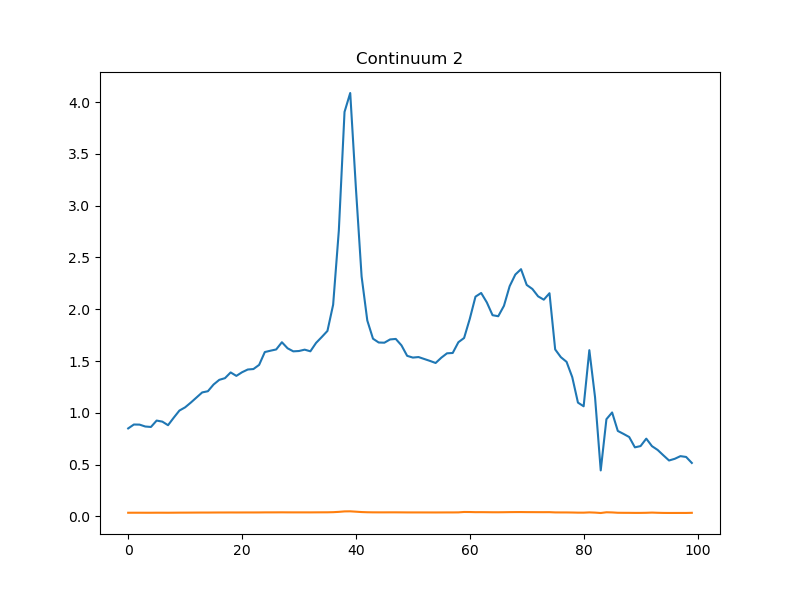

In [47]:
mask_continuum_2 = (wv > 5100)*(wv < 5400)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [48]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 31558.81114731479
differential_evolution step 2: f(x)= 9656.834219342953
differential_evolution step 3: f(x)= 7090.571063168358
differential_evolution step 4: f(x)= 6237.312752781454
differential_evolution step 5: f(x)= 6237.312752781454
differential_evolution step 6: f(x)= 6237.312752781454
differential_evolution step 7: f(x)= 3308.309129262175
differential_evolution step 8: f(x)= 111.65515472075442
differential_evolution step 9: f(x)= 111.65515472075442
differential_evolution step 10: f(x)= 111.65515472075442
differential_evolution step 11: f(x)= 111.65515472075442
differential_evolution step 12: f(x)= 111.65515472075442
differential_evolution step 13: f(x)= 111.65515472075442
differential_evolution step 14: f(x)= 111.65515472075442
differential_evolution step 15: f(x)= 111.65515472075442
differential_evolution step 16: f(x)= 111.65515472075442
differential_evolution step 17: f(x)= 111.65515472075442
differential_evolution step 18: f(x)= 111.65515

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\4157967734.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=4.2705, r_e=0.0847, n=4.6547, x_0=38.6571
Sérsic 2: I_e=0.3560, r_e=1.0867, n=0.5484, x_0=61.3172
Sérsic 3: I_e=0.4967, r_e=7.0992, n=0.6236, x_0=69.9049
Sérsic 4: I_e=0.0228, r_e=4.1931, n=0.7461, x_0=74.4073
Sérsic 5: I_e=0.4751, r_e=65.4504, n=0.8561, x_0=40.0005
Chi quadro minimo: 1.5396789042639127
False


Sérsic 1: I_e=4.2705, r_e=0.0847, n=4.6547, x_0=38.6571
Sérsic 2: I_e=0.3560, r_e=1.0867, n=0.5484, x_0=61.3172
Sérsic 3: I_e=0.4967, r_e=7.0992, n=0.6236, x_0=69.9049
Sérsic 4: I_e=0.0228, r_e=4.1931, n=0.7461, x_0=74.4073
Sérsic 5: I_e=0.4751, r_e=65.4504, n=0.8561, x_0=40.0005


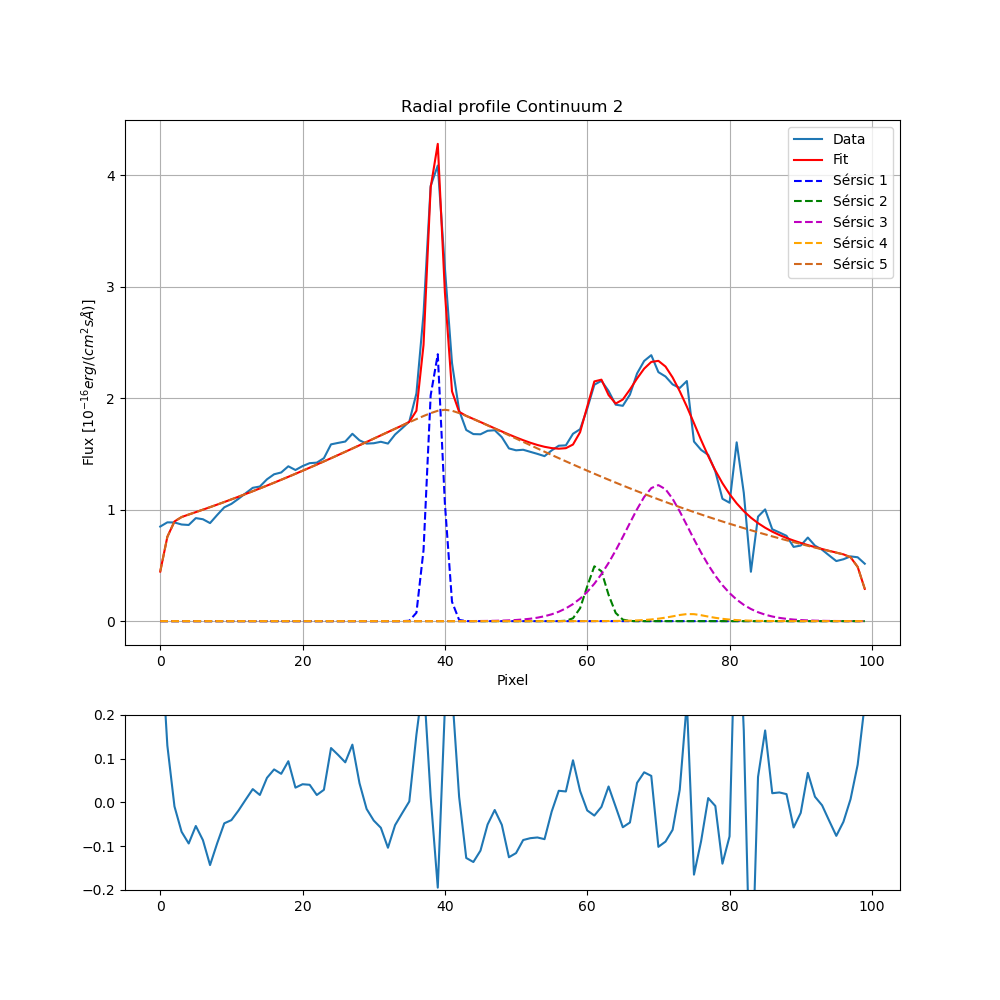

In [49]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [50]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.4791, r_e=1.0307, n=0.7064, x_0=38.6615
Sérsic 2: I_e=0.2782, r_e=3.1999, n=0.8338, x_0=61.7559
Sérsic 3: I_e=0.6469, r_e=3.7659, n=0.2423, x_0=70.0000
Sérsic 4: I_e=0.3075, r_e=6.3481, n=0.1000, x_0=74.0522
Sérsic 5: I_e=0.5275, r_e=60.9778, n=0.7751, x_0=40.0000
[ 2.39113836  0.53787682  1.50557555  0.12806399  0.39558666  2.64156907
  1.01366947  1.15131168  0.18379289  1.20783841  0.24462382  1.44026498
  0.34501218  6.10630218  0.26865088  1.66784825  0.16378589 15.67206584
  0.18789595  1.46685738]
3.7121016992277545


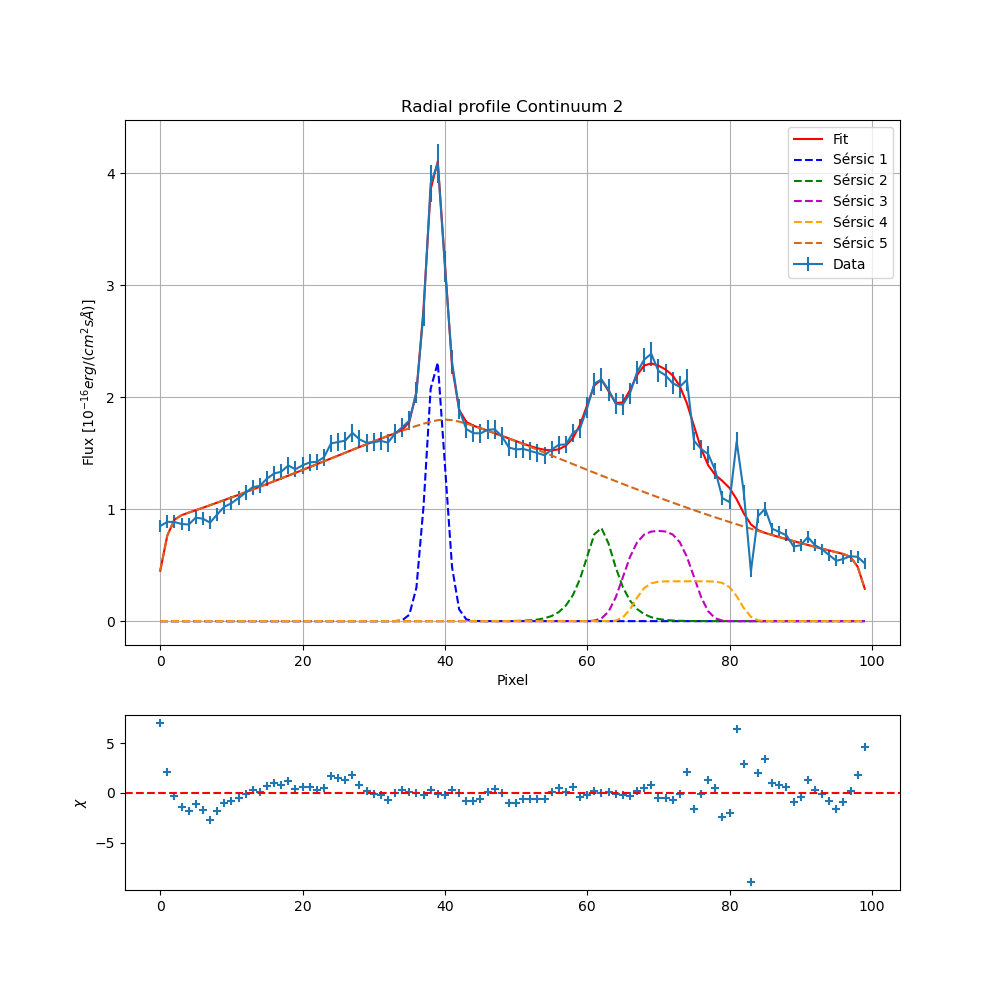

In [51]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

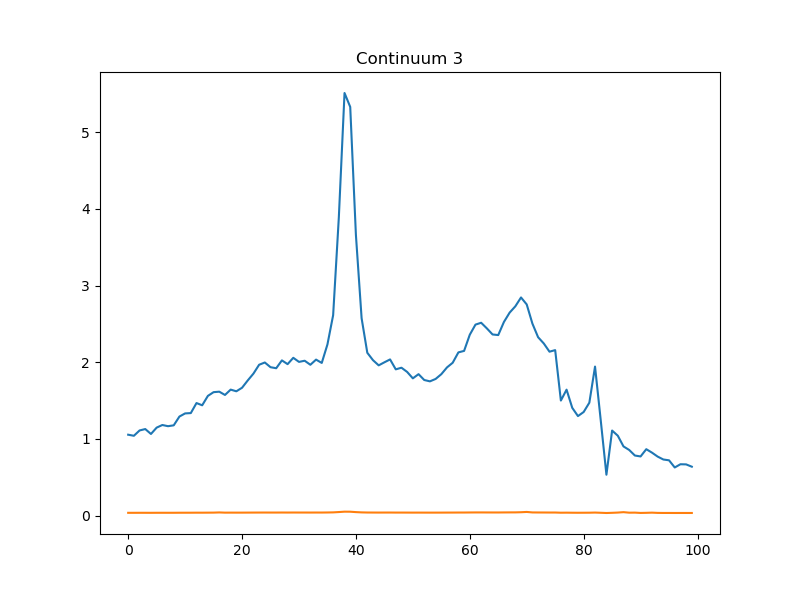

In [52]:
mask_continuum_3 = (wv > 5810)*(wv < 6210)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [53]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 42207.46010589828
differential_evolution step 2: f(x)= 20115.60735387541
differential_evolution step 3: f(x)= 20115.60735387541
differential_evolution step 4: f(x)= 20115.60735387541
differential_evolution step 5: f(x)= 16200.167628896454
differential_evolution step 6: f(x)= 7684.810240098339
differential_evolution step 7: f(x)= 6316.207655095276
differential_evolution step 8: f(x)= 5361.397451257688
differential_evolution step 9: f(x)= 2372.3697188883416
differential_evolution step 10: f(x)= 2372.3697188883416
differential_evolution step 11: f(x)= 2372.3697188883416
differential_evolution step 12: f(x)= 2372.3697188883416
differential_evolution step 13: f(x)= 2372.3697188883416
differential_evolution step 14: f(x)= 2372.3697188883416
differential_evolution step 15: f(x)= 1135.8411308246398
differential_evolution step 16: f(x)= 1088.9044169408805
differential_evolution step 17: f(x)= 404.5177411622201
differential_evolution step 18: f(x)= 404.517741

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\4157967734.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=1.5761, r_e=1.0864, n=1.0934, x_0=38.4129
Sérsic 2: I_e=0.2397, r_e=2.1889, n=0.6243, x_0=61.1518
Sérsic 3: I_e=0.3893, r_e=7.4043, n=0.8414, x_0=69.1853
Sérsic 4: I_e=0.3146, r_e=0.0109, n=2.6754, x_0=74.3428
Sérsic 5: I_e=0.8307, r_e=50.7939, n=0.6084, x_0=40.0000
Chi quadro minimo: 1.9375943696724693
False


Sérsic 1: I_e=1.5761, r_e=1.0864, n=1.0934, x_0=38.4129
Sérsic 2: I_e=0.2397, r_e=2.1889, n=0.6243, x_0=61.1518
Sérsic 3: I_e=0.3893, r_e=7.4043, n=0.8414, x_0=69.1853
Sérsic 4: I_e=0.3146, r_e=0.0109, n=2.6754, x_0=74.3428
Sérsic 5: I_e=0.8307, r_e=50.7939, n=0.6084, x_0=40.0000


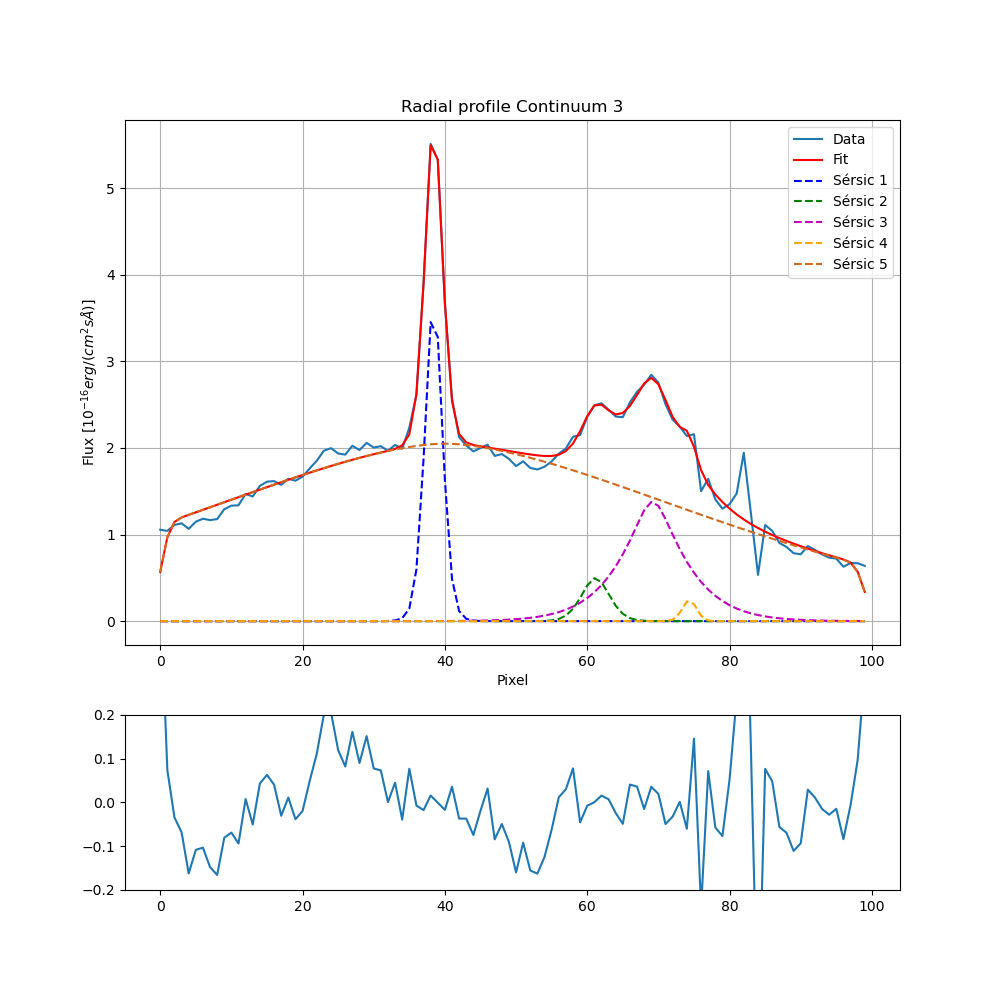

In [54]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [55]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\4157967734.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\4157967734.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18820\4157967734.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=2.9691, r_e=0.7978, n=0.5536, x_0=38.4572
Sérsic 2: I_e=0.2284, r_e=3.0839, n=0.6714, x_0=60.8796
Sérsic 3: I_e=0.3988, r_e=9.0689, n=0.8917, x_0=69.1895
Sérsic 4: I_e=0.3182, r_e=0.0080, n=2.6878, x_0=74.3428
Sérsic 5: I_e=0.5068, r_e=73.2873, n=0.9027, x_0=36.7882
[7.70720039e+00 3.96104349e-01 2.47652568e+00 1.19960501e-01
 3.42061874e-01 3.39181264e+00 1.09870178e+00 1.03720526e+00
 2.25724341e-01 3.60448782e+00 3.80809719e-01 8.28361906e-01
 3.37028146e+05 3.02620260e+03 1.12168152e+06 1.46860652e+02
 1.19841342e-01 1.50171505e+01 1.44570847e-01 1.44471192e+00]
4.510673595866934


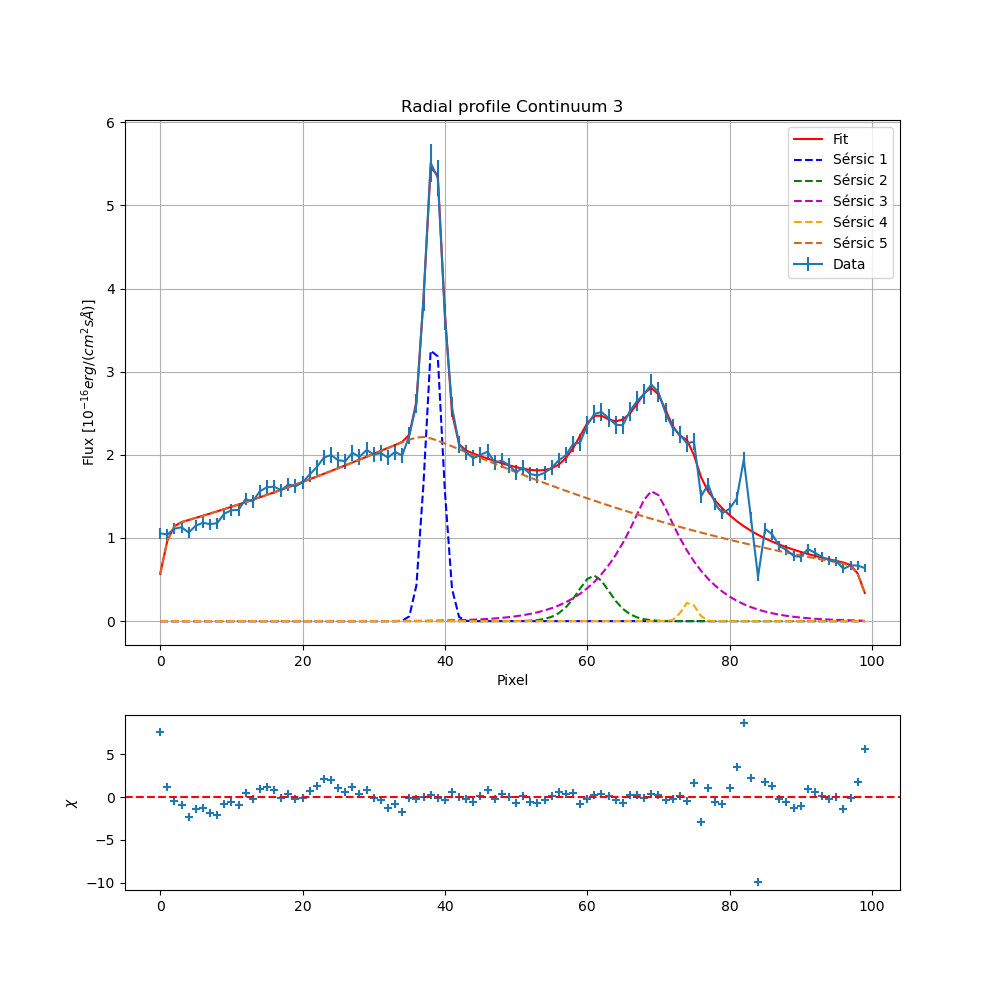

In [56]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [57]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

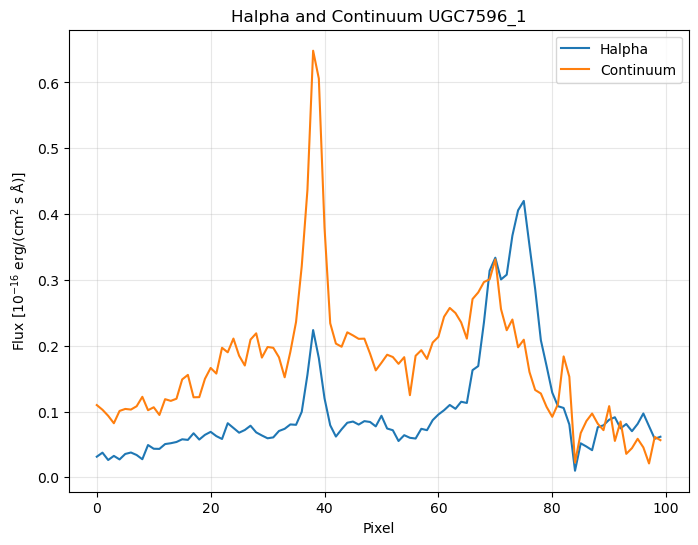

In [8]:
mask_continuum_3 = (wv > 6250)*(wv < 6300)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum UGC7596_1')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_UGC7596_1')